# T00158237 Machine Learning Project
This document is going to explore a simple Machine Learning Project. The topic is going to concern colour trends in vehicle manufacturing. In Ireland, distribution of colours within the data set is slanted towards shades, rather than colour, so predicting certain factors based on this data should give unique information that might serve to inform future decisionmaking.

## The Data Set
The data set was taken from the Irish Government website, [data.gov.ie](https://data.gov.ie/dataset/tea26-new-and-secondhand-vehicles)
The dataset contains the following columns:
- STATISIC - Always corresponds to the title of the dataset.
- STATISTIC LABEL - Value is always "New and Secondhand Vehicles"
- TLIST(A1) - This value is always the same as the "Year" Column.
- YEAR - The year. Always the same as previous column.
- C02172V02618 - Vehicle Type Classification. Represents the registration type of the vehicle. Same as "Taxation Class" Column. Can also be dropped.
- C03396V04087 - Always corresponds to color. Don't need this.
- Colour - String representation of the colour of the vehicle. Use this for categorical data.
- UNIT - This just says "Number" in every instance.
- Value - Total of cars sold within that category for that year. Can also be calculated by adding up all vehicles within that taxation class.

## Import Data set
The data set comes from the API located at [Central Statistics Office](https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/TEA26/CSV/1.0/en)
This is an API call, so don't hit it directly, use the code below.

In [45]:
import pandas as pd
import numpy as np
data_frame = pd.read_csv('https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/TEA26/CSV/1.0/en')
print(data_frame.head())

  STATISTIC              STATISTIC Label  TLIST(A1)  Year  C02172V02618  \
0     TEA26  New and Secondhand Vehicles       2010  2010            11   
1     TEA26  New and Secondhand Vehicles       2010  2010            11   
2     TEA26  New and Secondhand Vehicles       2010  2010            11   
3     TEA26  New and Secondhand Vehicles       2010  2010            11   
4     TEA26  New and Secondhand Vehicles       2010  2010            11   

     Taxation Class C03396V04087       Colour    UNIT    VALUE  
0  New Private Cars            -  All colours  Number  84907.0  
1  New Private Cars           01        Black  Number  20655.0  
2  New Private Cars           02         Grey  Number  14660.0  
3  New Private Cars           03        White  Number   1932.0  
4  New Private Cars           04        Beige  Number   1027.0  


# Clean the Data Set
Cleaning the Data Set reduces the number of redundant columns. Some columns in this set are effectively duplicates, meaning their value can be taken in easier ways from elsewhere in the set. There is a lot of categorical data here in the form of "Taxation Class" and "Colour" that would be useful for the model to manipulate.

In [46]:
def produce_data_set(): # No need for these columns they are mostly the same value, or correspond to the value in the next column.
  refactored_frame = data_frame.drop(columns=['STATISTIC', 'STATISTIC Label', 'TLIST(A1)', 'C02172V02618', 'C03396V04087', 'UNIT'])
  refactored_frame = refactored_frame.drop(refactored_frame[refactored_frame['Colour'] == 'All colours'].index) # Drop summary data there's no need for.
  refactored_frame = refactored_frame.drop(refactored_frame[refactored_frame['Taxation Class'].str.startswith('All')].index) # I only need the "All" rows, as 'New' and 'Secondhand' are summarical values."
  refactored_frame = refactored_frame.reset_index(drop=True)
  print(refactored_frame.head())
  #refactored_frame.to_csv('/content/drive/MyDrive/MachineLearningProjectData/Cleaned_set.csv') # Store it to my own drive.
  return refactored_frame
refactored_frame = produce_data_set()

   Year    Taxation Class Colour    VALUE
0  2010  New Private Cars  Black  20655.0
1  2010  New Private Cars   Grey  14660.0
2  2010  New Private Cars  White   1932.0
3  2010  New Private Cars  Beige   1027.0
4  2010  New Private Cars  Brown    949.0


# One Hot Encoder process
After researching the process, I have decided to go with OneHotEncoding() for the following reason:<hr>
Categorical changes: The categories on display here may change at some point, future data sets, for example, may have changes to the colour category, as the listed amount of colours present only 18 unique entries. This should keep this script reusable if it is ever revisited at any point.
This code organises the data into encoders for use in the model.
The encoders organise into categories that will be used to train the model.

In [47]:
from sklearn.preprocessing import OneHotEncoder
cat_features = ['Taxation Class', 'Colour']
encoders = {} # Must be stored in a dictionary

for feature in cat_features:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded_feature = encoder.fit_transform(refactored_frame[[feature]])
    feature_names = [f"{feature}_{cat}" for cat in encoder.categories_[0]]
    encoded_df = pd.DataFrame(encoded_feature, columns=feature_names)
    refactored_frame = pd.concat([refactored_frame, encoded_df], axis=1)
    encoders[feature] = encoder

print(refactored_frame.columns.tolist())

['Year', 'Taxation Class', 'Colour', 'VALUE', 'Taxation Class_New Goods Vehicles', 'Taxation Class_New Motor Cycles', 'Taxation Class_New Other Vehicles', 'Taxation Class_New Private Cars', 'Taxation Class_New Tractors', 'Taxation Class_Secondhand Goods Vehicles', 'Taxation Class_Secondhand Motor Cycles', 'Taxation Class_Secondhand Other Vehicles', 'Taxation Class_Secondhand Private Cars', 'Taxation Class_Secondhand Tractors', 'Colour_Beige', 'Colour_Black', 'Colour_Blue', 'Colour_Bronze', 'Colour_Brown', 'Colour_Gold', 'Colour_Green', 'Colour_Grey', 'Colour_Multi-coloured', 'Colour_Navy', 'Colour_Orange', 'Colour_Other', 'Colour_Pink', 'Colour_Purple', 'Colour_Red', 'Colour_Silver', 'Colour_White', 'Colour_Yellow']


## Creating Sequences for Convolutional Neural Network
[Useful Reading - Stanford](https://cs231n.github.io/convolutional-networks/)  
The process of creating a Neural Network involves creating sequences for the input.
This method organises the data set into input and output pairs that can be used to train a Convolutional Neural Network.

In [48]:
def create_sequences(data, years, lookback=3): # Function to make refactoring variables easier. Lookback describes how many previous years are assessed.
  X,y = [],[]
  for i in range(lookback, len(years)): # Get data for this period
    sequence = []
    for j in range(i - lookback, i):
      year_data = data[data['Year'] == years[j]]
      features = year_data.drop(['Year', 'Taxation Class', 'Colour', 'VALUE'], axis=1, errors='ignore')
      sequence.append(features.values[0])
    target_year = data[data['Year'] == years[i]]
    color_columns = [col for col in data.columns if col.startswith('Colour_')]
    target = target_year[color_columns].values[0]
    X.append(np.array(sequence))
    y.append(target)
  return np.array(X), np.array(y)

In [49]:
years = sorted(refactored_frame['Year'].unique()) # Sort the years

### Create Sequences
Create sequences using above method.

In [50]:
X,y = create_sequences(refactored_frame, years, lookback=5)

### Decide on Training Data
Training data and test data can be adjusted for accuracy. It was decided to use 80 percent of the data for training and 20 for testing. Because this is not a huge data set, there needs to be good data for training, meaning more of it should be used for training.

In [51]:
training_size = int(len(X) * 0.8) # 80% of available data is used for training
X_train, X_test = X[:training_size], X[training_size:]
y_train, y_test = y[:training_size], y[training_size:]

## Creating Neural Network

In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
def create_neural_network(input_shape, output_shape):
  model = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=input_shape),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(output_shape)
  ])
  model.compile(
    optimizer='adam',
    loss='mse', # Mean Squared Error for regression
    metrics=['mae'] # Mean Absolute Error
  )

  return model

## Insert Data into the Model
The model has test and train data inserted

In [53]:
input_shape = (X_train.shape[1], X_train.shape[2])
output_shape = y_train.shape[1]

model = create_neural_network(input_shape, output_shape)
history = model.fit(
  X_train, y_train,
  epochs=50,
  batch_size=8,
  validation_data=(X_test, y_test),
  verbose=1
)

mse, mae = model.evaluate(X_test, y_test)
print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0709 - mae: 0.1604 - val_loss: 0.0596 - val_mae: 0.1426
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.0681 - mae: 0.1505 - val_loss: 0.0547 - val_mae: 0.1316
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - loss: 0.0544 - mae: 0.1379 - val_loss: 0.0501 - val_mae: 0.1208
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.0536 - mae: 0.1311 - val_loss: 0.0459 - val_mae: 0.1118
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 0.0530 - mae: 0.1343 - val_loss: 0.0420 - val_mae: 0.1051
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.0479 - mae: 0.1228 - val_loss: 0.0384 - val_mae: 0.0989
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0434 - mae: 0.1178 - val_loss: 0.0351 - val_mae: 0.0932
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0378 - mae: 0.1056 - val_loss: 0.0321 - val_mae: 0.0885
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0337 - mae: 0.1007 - val_los

## Display Data
Use MatplotLib to display result data. In this case, the training loss and validation loss is displayed over the course of the training data.

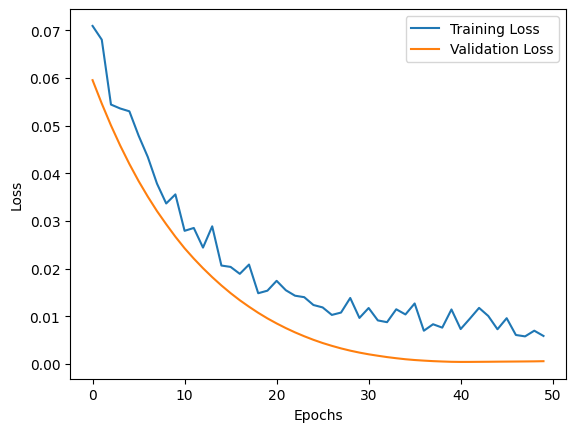

In [54]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Results and Conclusions
## Results
The results would seem to show a good result, with little underfitting or overfitting. This could indicate that the data set is uniform, and does not change much, which would be the likely conclusion. The decrease in value loss later would seem to indicate that the model works as intended.

## Conclusion
This could be a good indicator of model efficiency, but the true indicator of whether vehicle color would change much going forward is mostly down to economic factors. Economies aoften fluctuate greatly based on political realities, so this models predictions probably should not be taken too seriously.